# ESP-32 Proxy → Oil Health Monitoring Pipeline
## Kaggle Simulation Notebook

**Pipeline overview:**
1. Simulate an ESP-32 streaming `raw_adc` (turbidity), `temperature`, `capacitance_pF`
2. `SootCalibrationModel` — `raw_adc → Voltage → Soot %` via poly-3 fit on calibration data
   - Voltage conversion (Option B): `Voltage = (4095 − raw_adc) / 4095 × 100`
3. `model_params.npz` — polynomial regression → **temperature-proxy absorbance** (diagnostics only)
4. `TBNModel` — **temperature-driven second-order Arrhenius kinetics** → TBN % remaining
   - `d[TBN]/dt = −k₁(T)·TBN²`  where `k₁(T) = A·exp(−Eₐ/RT)`, Eₐ=60 kJ/mol
   - Integrated discretely per tick; accumulates thermal history
5. `OxidationIndexModel` — **temperature-driven first-order accumulation** → OI
   - `d[OI]/dt = k₂(T)·(OI_max − OI)`  where `k₂(T) = B·exp(−Eb/RT)`, Eb=55 kJ/mol
6. `DilutionModel` — raw_adc → Fuel Dilution %  (`Dilution = −21.4218 + 0.022253 × ADC`)
7. Assemble feature vector `[temp, soot_pct, cap_pF, TBN, oxidation_index, dilution]`
8. **KMeans (k=3)** → cluster assignment (HEALTHY / WARNING / DEGRADED)
9. **PCA PC1 loadings** → data-driven OHI feature weights
10. Weighted average → **Oil Health Index (0–100)**
11. Store every reading in **SQLite** (WAL mode)

**Changes vs previous version:**
- `TBNModel` rewritten: capacitance→Analexrs→Ridge path removed; now uses second-order
  Arrhenius kinetics driven by temperature history (Honda patent US7826987, Ea=60 kJ/mol)
- `OxidationIndexModel` rewritten: capacitance→Analexrs→linear path removed; now uses
  first-order accumulation kinetics driven by temperature history (Eb=55 kJ/mol)
- `analexrs` column retained in DB schema (set to 0.0) for backward compatibility
- `tbn_poly_model_fixed.npz` and `oi_cap_model.npz` no longer loaded


In [9]:
import os, pathlib

# ── Update this to match your Kaggle dataset folder name ──────────────────────
DATASET_SLUG = "oil-health-models5"   # folder name under /kaggle/input/

def _find(filename: str) -> str:
    kaggle_path = f"/kaggle/input/datasets/krishnasimha/{DATASET_SLUG}/{filename}"
    if os.path.exists(kaggle_path):
        return kaggle_path
    if os.path.exists(filename):
        return filename
    raise FileNotFoundError(
        f"Could not find '{filename}'.\n"
        f"  Kaggle path checked: {kaggle_path}\n"
        f"  Local path checked : {filename}\n"
        f"  → Upload the .npz files as a Kaggle dataset named '{DATASET_SLUG}'."
    )

MODEL_PARAMS_PATH = _find("model_params.npz")
# TBN_MODEL_PATH removed — TBNModel now uses Arrhenius kinetics, no .npz needed
# OI_CAP_MODEL_PATH removed — OxidationIndexModel now uses Arrhenius kinetics, no .npz needed

DB_PATH = "/kaggle/working/oil_health_sim.db" if os.path.exists("/kaggle/working") else "oil_health_sim.db"

# Soot calibration data (from Soot_Calibration.csv)
# Voltage column was measured as (4095 - Raw_ADC) / 4095 * 100  [Option B]
SOOT_CAL_DATA = [
    # (Raw_ADC, Voltage, Soot_pct)
    (3100, 24.50, 0.0350),
    (2150, 47.20, 0.0470),
    (1220, 70.00, 0.0706),
    (1058, 74.14, 0.0676),
    (1170, 70.40, 0.0667),
    (1450, 64.49, 0.0570),
    (2633, 35.53, 0.0400),
    ( 901, 78.00, 0.0800),
    ( 400, 90.23, 0.1140),
    ( 431, 89.69, 0.1080),
    ( 602, 85.30, 0.0930),
    ( 336, 91.55, 0.1300),
    ( 156, 96.19, 0.1680),
    ( 133, 96.75, 0.2180),
]

# Simulation settings
N_TICKS       = 300
RNG_SEED      = 42
RETRAIN_EVERY = 30
MIN_TRAIN     = 30

print(f"model_params  → {MODEL_PARAMS_PATH}")
print(f"SQLite DB     → {DB_PATH}")
print(f"Ticks         = {N_TICKS}")


model_params  → /kaggle/input/datasets/krishnasimha/oil-health-models5/model_params.npz
SQLite DB     → /kaggle/working/oil_health_sim.db
Ticks         = 300


In [10]:
import threading
import sqlite3
import math
import json
import warnings
from dataclasses import dataclass
from typing import List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler, PolynomialFeatures
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore", category=FutureWarning)
plt.rcParams.update({"figure.dpi": 130, "axes.spines.top": False, "axes.spines.right": False})
print("All imports OK")


All imports OK


In [11]:
# ── Feature list ─────────────────────────────────────────────────────────────
# dilution added as 6th feature (fuel dilution % from dilution_adc — separate sensor)
FEATURES = ["temperature", "soot_pct", "capacitance_pF", "tbn", "oxidation_index", "dilution"]

THRESHOLDS = {
    "temperature":     {"direction": "below", "max": 110.0},  # > 110°C  = degraded
    "soot_pct":        {"direction": "below", "max":   0.10}, # > 0.10%  = degraded
    "capacitance_pF":  {"direction": "above", "min":  50.0},  # < 50 pF  = degraded
    "tbn":             {"direction": "above", "min":  40.0},  # < 40%    = degraded
    "oxidation_index": {"direction": "below", "max":  30.0},  # > 30     = degraded
    "dilution":        {"direction": "below", "max":   5.0},  # > 5%     = degraded
}

@dataclass
class ESP32Packet:
    """Raw sensor packet from the simulated ESP-32 node."""
    timestamp:       float
    engine_hours:    float
    temperature:     float   # °C
    raw_adc:         int     # 0–4095, turbidity sensor (soot)
    dilution_adc:    int     # 0–4095, separate optical sensor for fuel dilution
    capacitance_pF:  float   # pF  (simulation: 5–80 pF Analexrs-scale)

@dataclass
class ProcessedReading:
    """Fully processed reading stored to SQLite."""
    timestamp:       float
    engine_hours:    float
    temperature:     float
    raw_adc:         int
    dilution_adc:    int
    soot_pct:        float   # raw_adc → Voltage → Soot% via calibration
    capacitance_pF:  float
    analexrs:        float   # capacitance_pF converted to Analexrs scale
    tbn:             float   # TBN % remaining, from [Analexrs, tbn_init] via Ridge model
    oxidation_index: float   # OI = IR_area / 0.0105, from Analexrs via Fig 8b regression
    dilution:        float   # fuel dilution %, from dilution_adc: -21.4218 + 0.022253 * ADC
    cluster:         int
    cluster_label:   str
    ohi:             int
    pca_weights:     str     # JSON

print("Dataclasses and thresholds defined")
print(f"Features: {FEATURES}")


Dataclasses and thresholds defined
Features: ['temperature', 'soot_pct', 'capacitance_pF', 'tbn', 'oxidation_index', 'dilution']


In [12]:
class SootCalibrationModel:
    """
    Converts turbidity sensor Raw ADC → Soot % using calibration data.

    Two-step pipeline (Option B):
      1. Voltage = (4095 - raw_adc) / 4095 * 100
      2. Soot % = poly3(Voltage)

    Voltage is clamped to [24.5, 96.75] before poly eval.
    """

    ADC_MAX  = 4095
    V_MIN    =  24.5
    V_MAX    =  96.75
    SOOT_MIN =   0.0
    SOOT_MAX =   0.25

    def __init__(self, cal_data: list = SOOT_CAL_DATA):
        voltages  = np.array([row[1] for row in cal_data])
        soot_pcts = np.array([row[2] for row in cal_data])
        self.coeffs = np.polyfit(voltages, soot_pcts, 3)
        y_hat = np.polyval(self.coeffs, voltages)
        ss_res = np.sum((soot_pcts - y_hat) ** 2)
        ss_tot = np.sum((soot_pcts - soot_pcts.mean()) ** 2)
        r2   = 1 - ss_res / ss_tot
        rmse = float(np.sqrt(np.mean((soot_pcts - y_hat) ** 2)))
        print(f"[SOOT] Poly-3 fit  R²={r2:.4f}  RMSE={rmse:.5f}")
        print(f"       coeffs={np.round(self.coeffs, 8)}")

    def adc_to_voltage(self, raw_adc: int) -> float:
        return (self.ADC_MAX - raw_adc) / self.ADC_MAX * 100.0

    def predict(self, raw_adc: int) -> float:
        voltage = self.adc_to_voltage(raw_adc)
        voltage_clamped = max(self.V_MIN, min(self.V_MAX, voltage))
        soot = float(np.polyval(self.coeffs, voltage_clamped))
        return round(max(self.SOOT_MIN, min(self.SOOT_MAX, soot)), 6)

_soot_chk = SootCalibrationModel(SOOT_CAL_DATA)
print()
print(f"{'Raw ADC':>8}  {'Voltage':>8}  {'Soot %':>8}")
print("─" * 32)
for adc in [3100, 2000, 1000, 400, 133]:
    v    = _soot_chk.adc_to_voltage(adc)
    soot = _soot_chk.predict(adc)
    print(f"{adc:>8d}  {v:>8.2f}  {soot:>8.4f}")
print()
print("Fresh oil (ADC≈3100) → low Soot %, degraded (ADC≈133) → high Soot %")


[SOOT] Poly-3 fit  R²=0.9217  RMSE=0.01397
       coeffs=[ 1.5700000e-06 -2.4507000e-04  1.2509320e-02 -1.5476387e-01]

 Raw ADC   Voltage    Soot %
────────────────────────────────
    3100     24.30    0.0277
    2000     51.16    0.0537
    1000     75.58    0.0675
     400     90.23    0.1302
     133     96.75    0.1810

Fresh oil (ADC≈3100) → low Soot %, degraded (ADC≈133) → high Soot %


In [13]:
class TempAbsorbanceProxy:
    """
    Temperature-based absorbance proxy loaded from model_params.npz.
    Retained for diagnostics only — NOT part of the main feature vector.
    """

    def __init__(self, path: str = MODEL_PARAMS_PATH):
        d = np.load(path)
        self.ir_scale   = float(d["ir_area_scale"])
        self.lub_coeffs = d["lub_poly_coeffs_full"]
        self.anx_coeffs = d["anx_poly_coeffs_full"]
        print(f"[TEMP_ABS]  ir_scale={self.ir_scale}  "
              f"lub_degree={len(self.lub_coeffs)-1}  anx_degree={len(self.anx_coeffs)-1}")

    @staticmethod
    def _poly(coeffs: np.ndarray, x: float) -> float:
        return float(sum(c * x**i for i, c in enumerate(coeffs)))

    def predict(self, temperature: float) -> float:
        lub = self._poly(self.lub_coeffs, temperature) * self.ir_scale
        anx = self._poly(self.anx_coeffs, temperature) * self.ir_scale
        return round((lub + anx) / 2.0, 6)

_abs_chk = TempAbsorbanceProxy(MODEL_PARAMS_PATH)
for _t in [70, 90, 110, 130]:
    print(f"  T={_t:3d}°C  →  temp_abs_proxy={_abs_chk.predict(_t):.5f}")
print("(Diagnostics only — not used as OHI feature)")


[TEMP_ABS]  ir_scale=0.0105  lub_degree=5  anx_degree=4
  T= 70°C  →  temp_abs_proxy=0.26813
  T= 90°C  →  temp_abs_proxy=0.24075
  T=110°C  →  temp_abs_proxy=0.21406
  T=130°C  →  temp_abs_proxy=0.20480
(Diagnostics only — not used as OHI feature)


In [14]:
class TBNModel:
    """
    Predicts TBN % remaining using second-order Arrhenius thermal kinetics.

    Physical basis (Honda patent US7826987 / US8464576):
      The TBN decrease rate under thermal exposure follows second-order kinetics:
        d[TBN]/dt = −k₁(T) · TBN²
      where k₁ is Arrhenius-type:
        k₁(T) = A · exp(−Eₐ / R·T)   [T in Kelvin]

    Integrated discretely per tick (Euler step, dt in hours):
        TBN[t+1] = TBN[t] / (1 + TBN[t] · k₁(T[t]) · dt)

    Parameters (mineral engine oil defaults):
      Eₐ  = 60,000 J/mol   (activation energy, literature range 50–80 kJ/mol)
      A   = 1.2e-4  h⁻¹   (pre-exponential factor, fitted to ~50% TBN depletion
                            at 100°C over 250 engine hours)
      R   = 8.314 J/mol·K

    Usage:
      model = TBNModel(tbn_init=92.78)   # fresh oil TBN %
      model.reset()                       # call at session start
      tbn = model.step(temperature_C, dt_hours)   # call each tick
    """

    EA   = 60_000.0   # J/mol — activation energy
    A    = 1.081e4     # h⁻¹  — pre-exponential factor
    R    = 8.314      # J/mol·K
    TBN_MIN = 20.0    # % — lower bound (fully depleted)
    TBN_MAX = 100.0   # % — upper bound (fresh oil)

    def __init__(self, tbn_init: float = 92.78):
        self.tbn_init = tbn_init
        self._tbn = tbn_init

    def reset(self, tbn_init: float = None):
        """Reset state to fresh oil. Call at start of each session."""
        if tbn_init is not None:
            self.tbn_init = tbn_init
        self._tbn = self.tbn_init

    def k1(self, temperature_C: float) -> float:
        """Arrhenius rate constant k₁ at given temperature (°C)."""
        T_K = temperature_C + 273.15
        return self.A * math.exp(-self.EA / (self.R * T_K))

    def step(self, temperature_C: float, dt_hours: float = 0.4) -> float:
        """
        Advance TBN by one tick of duration dt_hours at temperature_C.
        Returns current TBN % (clamped to [TBN_MIN, TBN_MAX]).
        """
        k = self.k1(temperature_C)
        # Discrete second-order Euler step:
        #   TBN[t+1] = TBN[t] / (1 + TBN[t] · k · dt)
        self._tbn = self._tbn / (1.0 + self._tbn * k * dt_hours)
        self._tbn = max(self.TBN_MIN, min(self.TBN_MAX, self._tbn))
        return round(self._tbn, 4)

    @property
    def current(self) -> float:
        """Current TBN % without advancing the state."""
        return round(self._tbn, 4)


# ── Sanity check ─────────────────────────────────────────────────────────────
_tbn_chk = TBNModel(tbn_init=92.78)
_tbn_chk.reset()
print(f"[TBN]  Second-order Arrhenius  Eₐ={TBNModel.EA/1000:.0f} kJ/mol  A={TBNModel.A}")
print(f"       k₁(70°C)={_tbn_chk.k1(70):.3e}  k₁(100°C)={_tbn_chk.k1(100):.3e}  k₁(130°C)={_tbn_chk.k1(130):.3e}")
print()

# Simulate 250 engine hours at constant temperatures to verify depletion rates
print(f"{'Hours':>6}  {'T=70°C':>8}  {'T=100°C':>9}  {'T=130°C':>9}")
print("─" * 40)
dt = 0.4  # hours per tick
for target_h in [0, 50, 100, 150, 200, 250]:
    m70  = TBNModel(92.78); m70.reset()
    m100 = TBNModel(92.78); m100.reset()
    m130 = TBNModel(92.78); m130.reset()
    for _ in range(int(target_h / dt)):
        m70.step(70, dt); m100.step(100, dt); m130.step(130, dt)
    print(f"{target_h:>6}  {m70.current:>8.2f}%  {m100.current:>9.2f}%  {m130.current:>9.2f}%")
print()
print("Second-order kinetics: depletion accelerates at high temperature.")


[TBN]  Second-order Arrhenius  Eₐ=60 kJ/mol  A=10810.0
       k₁(70°C)=7.948e-06  k₁(100°C)=4.311e-05  k₁(130°C)=1.818e-04

 Hours    T=70°C    T=100°C    T=130°C
────────────────────────────────────────
     0     92.78%      92.78%      92.78%
    50     89.48%      77.32%      50.33%
   100     86.41%      66.27%      34.53%
   150     83.54%      57.99%      26.28%
   200     80.86%      51.55%      21.22%
   250     78.34%      46.39%      20.00%

Second-order kinetics: depletion accelerates at high temperature.


In [15]:
class OxidationIndexModel:
    """
    Predicts Oxidation Index (OI) using first-order Arrhenius accumulation kinetics.

    Physical basis:
      Oxidation products accumulate as temperature rises — TAN and OI increase
      exponentially with temperature (US patent 6920779; Corrosion sensor paper
      ASTM D974). First-order approach-to-saturation kinetics:
        d[OI]/dt = k₂(T) · (OI_max − OI)
      where k₂ is Arrhenius-type:
        k₂(T) = B · exp(−Eb / R·T)   [T in Kelvin]

    Integrated discretely per tick (Euler step, dt in hours):
        OI[t+1] = OI[t] + k₂(T[t]) · (OI_max − OI[t]) · dt

    Parameters:
      Eb      = 55,000 J/mol   (slightly lower than TBN Eₐ — oxidation is
                                somewhat less temperature-sensitive than base
                                depletion; consistent with ASTM D2272 RBOT data)
      B       = 5.843e4  h⁻¹   (pre-exponential; fitted to reach OI≈30 warning
                                threshold at ~150 engine hours at 100°C)
      OI_max  = 100.0          (saturation limit — fully oxidised oil)
      OI_init =  16.6          (fresh oil baseline from Gomółka & Augustynowicz 2019)

    Usage:
      model = OxidationIndexModel()
      model.reset()
      oi = model.step(temperature_C, dt_hours)   # call each tick
    """

    EB      = 55_000.0   # J/mol — activation energy for oxidation
    B       = 5.843e4     # h⁻¹  — pre-exponential factor
    R       = 8.314      # J/mol·K
    OI_MAX  = 100.0      # saturation (fully oxidised)
    OI_INIT =  16.6      # fresh oil baseline (Gomółka & Augustynowicz 2019)

    def __init__(self):
        self._oi = self.OI_INIT

    def reset(self):
        """Reset to fresh oil OI. Call at start of each session."""
        self._oi = self.OI_INIT

    def k2(self, temperature_C: float) -> float:
        """Arrhenius rate constant k₂ at given temperature (°C)."""
        T_K = temperature_C + 273.15
        return self.B * math.exp(-self.EB / (self.R * T_K))

    def step(self, temperature_C: float, dt_hours: float = 0.4) -> float:
        """
        Advance OI by one tick of duration dt_hours at temperature_C.
        Returns current OI (clamped to [OI_INIT, OI_MAX]).
        """
        k = self.k2(temperature_C)
        self._oi = self._oi + k * (self.OI_MAX - self._oi) * dt_hours
        self._oi = max(self.OI_INIT, min(self.OI_MAX, self._oi))
        return round(self._oi, 4)

    @property
    def current(self) -> float:
        """Current OI without advancing the state."""
        return round(self._oi, 4)


# ── Sanity check ─────────────────────────────────────────────────────────────
_oi_chk = OxidationIndexModel()
_oi_chk.reset()
print(f"[OI]   First-order Arrhenius accumulation  Eb={OxidationIndexModel.EB/1000:.0f} kJ/mol  B={OxidationIndexModel.B}")
print(f"       k₂(70°C)={_oi_chk.k2(70):.3e}  k₂(100°C)={_oi_chk.k2(100):.3e}  k₂(130°C)={_oi_chk.k2(130):.3e}")
print()

print(f"{'Hours':>6}  {'T=70°C':>8}  {'T=100°C':>9}  {'T=130°C':>9}")
print("─" * 40)
dt = 0.4
for target_h in [0, 50, 100, 150, 200, 250]:
    m70  = OxidationIndexModel(); m70.reset()
    m100 = OxidationIndexModel(); m100.reset()
    m130 = OxidationIndexModel(); m130.reset()
    for _ in range(int(target_h / dt)):
        m70.step(70, dt); m100.step(100, dt); m130.step(130, dt)
    print(f"{target_h:>6}  {m70.current:>8.2f}   {m100.current:>9.2f}   {m130.current:>9.2f}")
print()
print("OI > 30 triggers DEGRADED threshold.")
print("First-order: accumulation slows as OI approaches OI_max=100.")


[OI]   First-order Arrhenius accumulation  Eb=55 kJ/mol  B=58430.0
       k₂(70°C)=2.478e-04  k₂(100°C)=1.168e-03  k₂(130°C)=4.368e-03

 Hours    T=70°C    T=100°C    T=130°C
────────────────────────────────────────
     0     16.60       16.60       16.60
    50     17.63       21.33       32.97
   100     18.64       25.79       46.13
   150     19.64       30.00       56.71
   200     20.63       33.97       65.21
   250     21.61       37.72       72.04

OI > 30 triggers DEGRADED threshold.
First-order: accumulation slows as OI approaches OI_max=100.


In [16]:
class DilutionModel:
    """
    Predicts fuel dilution (%) from a dedicated dilution optical ADC.

    This is a SEPARATE sensor from the turbidity/soot ADC (raw_adc).
    Linear calibration (n=6, R²=0.78, RMSE=0.79%):
      Dilution = -21.4218 + 0.022253 × dilution_adc

    Calibration range: ADC 1130–1328 → Dilution 3.56–8.51 %
    No output clamping — the dedicated sensor stays within calibration range
    during normal operation. Input is clipped to [1130, 1328] to prevent
    extrapolation if the sensor drifts outside calibration bounds.
    """

    INTERCEPT = -21.4218
    SLOPE     =   0.022253
    ADC_MIN   = 1130
    ADC_MAX   = 1328

    def predict(self, dilution_adc: int) -> float:
        adc_clamped = max(self.ADC_MIN, min(self.ADC_MAX, dilution_adc))
        return round(self.INTERCEPT + self.SLOPE * adc_clamped, 4)

_dil_chk = DilutionModel()
print(f"[DILUTION]  Dilution = {DilutionModel.INTERCEPT} + {DilutionModel.SLOPE} × dilution_adc")
print(f"            Input clamped to calibration range [{DilutionModel.ADC_MIN}, {DilutionModel.ADC_MAX}]")
print()
print(f"{'dilution_adc':>13}  {'Dilution%':>10}")
print("─" * 26)
for _a in [1130, 1150, 1187, 1200, 1250, 1300, 1328]:
    print(f"{_a:>13}  {_dil_chk.predict(_a):>10.3f}")


[DILUTION]  Dilution = -21.4218 + 0.022253 × dilution_adc
            Input clamped to calibration range [1130, 1328]

 dilution_adc   Dilution%
──────────────────────────
         1130       3.724
         1150       4.169
         1187       4.992
         1200       5.282
         1250       6.394
         1300       7.507
         1328       8.130


In [17]:
class OilHealthDB:
    """
    SQLite store with WAL mode.

    Schema vs previous version:
      + dilution_adc  INTEGER — raw ADC from the dedicated dilution sensor
      + dilution      REAL    — fuel dilution % from DilutionModel
    """

    def __init__(self, path: str = DB_PATH):
        os.makedirs(os.path.dirname(path) if os.path.dirname(path) else ".", exist_ok=True)
        if os.path.exists(path):
            os.remove(path)
        self._lock = threading.Lock()
        self._conn = sqlite3.connect(path, check_same_thread=False)
        self._conn.execute("PRAGMA journal_mode=WAL")
        self._conn.execute("PRAGMA synchronous=NORMAL")
        self._conn.execute("PRAGMA cache_size=-4096")
        self._conn.execute("""
            CREATE TABLE IF NOT EXISTS readings (
                id               INTEGER PRIMARY KEY,
                timestamp        REAL    NOT NULL,
                engine_hours     REAL    NOT NULL,
                temperature      REAL    NOT NULL,
                raw_adc          INTEGER NOT NULL,
                dilution_adc     INTEGER NOT NULL,
                soot_pct         REAL    NOT NULL,
                capacitance_pF   REAL    NOT NULL,
                analexrs         REAL    NOT NULL,
                tbn              REAL    NOT NULL,
                oxidation_index  REAL    NOT NULL,
                dilution         REAL    NOT NULL,
                cluster          INTEGER NOT NULL,
                cluster_label    TEXT    NOT NULL,
                ohi              INTEGER NOT NULL,
                pca_weights      TEXT    NOT NULL
            )
        """)
        self._conn.execute(
            "CREATE INDEX IF NOT EXISTS idx_readings_hours ON readings (engine_hours)"
        )
        self._conn.commit()
        print(f"[DB]   SQLite ready  →  {path}")

    def insert(self, r: ProcessedReading):
        with self._lock:
            self._conn.execute(
                """INSERT INTO readings
                   (timestamp, engine_hours, temperature, raw_adc, dilution_adc, soot_pct,
                    capacitance_pF, analexrs, tbn, oxidation_index, dilution,
                    cluster, cluster_label, ohi, pca_weights)
                   VALUES (?,?,?,?,?,?,?,?,?,?,?,?,?,?,?)""",
                (r.timestamp, r.engine_hours, r.temperature, r.raw_adc, r.dilution_adc,
                 r.soot_pct, r.capacitance_pF, r.analexrs, r.tbn, r.oxidation_index,
                 r.dilution, r.cluster, r.cluster_label, r.ohi, r.pca_weights),
            )
            self._conn.commit()

    def to_dataframe(self):
        with self._lock:
            return pd.read_sql("SELECT * FROM readings ORDER BY id", self._conn)

    def close(self):
        with self._lock:
            self._conn.execute("PRAGMA wal_checkpoint(TRUNCATE)")
            self._conn.close()
        print("[DB]   Connection closed.")

print("OilHealthDB defined")


OilHealthDB defined


In [18]:
class OHIEngine:
    """
    KMeans (k=3) + PCA-derived weights → Oil Health Index.
    Feature vector: [temperature, soot_pct, capacitance_pF, tbn, oxidation_index, dilution]
    """

    FEAT_MIN = np.array([ 40.0,  0.000,  20.0,  20.0,   0.0,  0.0], dtype=np.float32)
    FEAT_MAX = np.array([150.0,  0.250, 120.0, 100.0, 100.0, 15.0], dtype=np.float32)

    def __init__(self):
        self.scaler  = MinMaxScaler()
        self.kmeans  = None
        self.pca     = PCA(n_components=1)
        self.weights = {f: 1.0 / len(FEATURES) for f in FEATURES}
        self.labels  = []
        self.trained = False
        self._lock   = threading.Lock()

    def train(self, X: np.ndarray, verbose: bool = True):
        if X.shape[0] < 9:
            return
        with self._lock:
            X_norm = self.scaler.fit_transform(X)
            self.kmeans = KMeans(n_clusters=3, init="k-means++", n_init=10,
                                 max_iter=300, random_state=42)
            self.kmeans.fit(X_norm)

            centroids_raw = self.scaler.inverse_transform(self.kmeans.cluster_centers_)
            vscores = []
            for c in centroids_raw:
                v = 0
                for i, feat in enumerate(FEATURES):
                    t, val = THRESHOLDS.get(feat, {}), c[i]
                    if t.get("direction") == "above" and val < t.get("min", 0):
                        v += 2
                    elif t.get("direction") == "below" and val > t.get("max", 9999):
                        v += 1
                vscores.append(v)
            order = np.argsort(vscores)
            lmap  = [""] * 3
            for rank, ci in enumerate(order):
                if rank == 0:   lmap[ci] = "HEALTHY"
                elif rank == 2: lmap[ci] = "DEGRADED"
                else:           lmap[ci] = "WARNING"
            self.labels = lmap

            self.pca.fit(X_norm)
            loadings = np.abs(self.pca.components_[0])
            w = loadings / (loadings.sum() + 1e-9)
            self.weights = {feat: round(float(w[i]), 4) for i, feat in enumerate(FEATURES)}
            self.trained = True

        if verbose:
            print(f"  [OHI] trained  inertia={self.kmeans.inertia_:.3f}  "
                  f"PC1_var={self.pca.explained_variance_ratio_[0]:.3f}  "
                  f"labels={self.labels}  weights={self.weights}")

    def save(self, path: str = "ohi_engine.npz") -> None:
        """Persist trained KMeans centroids, scaler, PCA weights to .npz."""
        if not self.trained:
            raise RuntimeError("OHIEngine not trained yet — call train() first.")
        with self._lock:
            np.savez(
                path,
                # KMeans
                cluster_centers    = self.kmeans.cluster_centers_,       # (3, 6) normalised
                cluster_labels     = np.array(self.labels),              # (3,) str
                kmeans_inertia     = np.array([self.kmeans.inertia_]),
                # Scaler (MinMaxScaler — need min/max to invert centroids)
                scaler_data_min    = self.scaler.data_min_,              # (6,)
                scaler_data_max    = self.scaler.data_max_,              # (6,)
                # PCA
                pca_components     = self.pca.components_,               # (1, 6)
                pca_explained_var  = self.pca.explained_variance_ratio_, # (1,)
                # Derived OHI weights + feature order
                feature_names      = np.array(FEATURES),                 # (6,) str
                ohi_weights        = np.array([self.weights[f] for f in FEATURES]),  # (6,)
            )
        print(f"[OHI] model saved → {path}")

    @classmethod
    def load(cls, path: str = "ohi_engine.npz") -> "OHIEngine":
        """Restore a trained OHIEngine from .npz (inference-only, no re-fit needed)."""
        d   = np.load(path, allow_pickle=False)
        eng = cls()

        # Reconstruct MinMaxScaler (only data_min_ / data_max_ needed for transform)
        eng.scaler.data_min_       = d["scaler_data_min"]
        eng.scaler.data_max_       = d["scaler_data_max"]
        eng.scaler.data_range_     = eng.scaler.data_max_ - eng.scaler.data_min_
        eng.scaler.scale_          = 1.0 / (eng.scaler.data_range_ + 1e-8)
        eng.scaler.n_features_in_  = len(eng.scaler.data_min_)

        # Reconstruct KMeans (predict-only)
        eng.kmeans = KMeans(n_clusters=3)
        eng.kmeans.cluster_centers_ = d["cluster_centers"]
        eng.kmeans.n_features_in_   = d["cluster_centers"].shape[1]
        eng.kmeans._n_threads       = 1

        eng.labels = list(d["cluster_labels"].astype(str))

        # Reconstruct PCA (predict-only)
        eng.pca.components_               = d["pca_components"]
        eng.pca.explained_variance_ratio_ = d["pca_explained_var"]

        # Weights
        feats = list(d["feature_names"].astype(str))
        wvals = d["ohi_weights"]
        eng.weights = {f: float(w) for f, w in zip(feats, wvals)}
        eng.trained = True

        print(f"[OHI] model loaded ← {path}")
        print(f"       labels={eng.labels}  weights={eng.weights}")
        return eng

    def predict(self, feat_vec: np.ndarray):
        with self._lock:
            if not self.trained or self.kmeans is None:
                return 0, "HEALTHY", 50
            X_norm = np.clip(
                (feat_vec.reshape(1, -1) - self.scaler.data_min_) /
                (self.scaler.data_range_ + 1e-8),
                0.0, 1.0
            )
            cluster = int(self.kmeans.predict(X_norm)[0])
            label   = self.labels[cluster] if self.labels else "UNKNOWN"

            health = np.zeros(len(FEATURES), dtype=np.float32)
            for i, feat in enumerate(FEATURES):
                t    = THRESHOLDS.get(feat, {})
                norm = float(np.clip(
                    (feat_vec[i] - self.FEAT_MIN[i]) /
                    (self.FEAT_MAX[i] - self.FEAT_MIN[i] + 1e-8), 0, 1))
                health[i] = norm if t.get("direction") == "above" else 1.0 - norm

            ohi = sum(self.weights.get(f, 1/len(FEATURES)) * float(health[i])
                      for i, f in enumerate(FEATURES))
            return cluster, label, max(0, min(100, int(ohi * 100)))

print("OHIEngine defined  (save / load methods bound)")


OHIEngine defined  (save / load methods bound)


In [19]:
OHI_MODEL_PATH = "/kaggle/working/ohi_engine.npz" if os.path.exists("/kaggle/working") else "ohi_engine.npz"
print(f"OHI model will be saved → {OHI_MODEL_PATH}")


OHI model will be saved → /kaggle/working/ohi_engine.npz


In [20]:
def generate_esp32_packets(n_ticks: int = N_TICKS,
                            hours_per_step: float = 0.4,
                            seed: int = RNG_SEED) -> List[ESP32Packet]:
    """
    Pre-generates all ESP-32 packets synchronously (no sleep) for Kaggle compatibility.

    Degradation model over 250 simulated engine hours:
      temperature   : 70°C  → 130°C
      raw_adc       : 3100  → 133       (turbidity — soot buildup)
      capacitance   : 80 pF → 25 pF     (dielectric loss)
      dilution_adc  : 1130  → 1328      (dedicated dilution sensor;
                                          higher ADC = more fuel dilution)

    dilution_adc increases with degradation (fuel dilution worsens over engine hours).
    Range kept within [1130, 1328] — the calibration range of DilutionModel.
    """
    rng     = np.random.default_rng(seed)
    packets = []
    for t in range(n_ticks):
        eng_hours = t * hours_per_step
        progress  = min(eng_hours / 250.0, 1.0)

        temperature    = 70.0  + 60.0  * progress**1.5  + rng.normal(0, 1.5)
        raw_adc_float  = 3100.0 - 2967.0 * progress**1.2 + rng.normal(0, 30)
        capacitance_pF = 80.0  - 55.0  * progress**1.2  + rng.normal(0, 1.0)
        dilution_adc_f = 1130.0 + 198.0 * progress**1.2  + rng.normal(0, 10)

        packets.append(ESP32Packet(
            timestamp      = t * 1.0,
            engine_hours   = round(eng_hours, 3),
            temperature    = round(max(50.0, temperature), 2),
            raw_adc        = int(max(133, min(3100, raw_adc_float))),
            dilution_adc   = int(max(1130, min(1328, dilution_adc_f))),
            capacitance_pF = round(max(5.0, min(120.0, capacitance_pF)), 2),
        ))
    print(f"Generated {len(packets)} ESP-32 packets  "
          f"(engine hours: 0 → {packets[-1].engine_hours:.1f}h)")
    print(f"Turbidity ADC range : {min(p.raw_adc for p in packets)} → {max(p.raw_adc for p in packets)}")
    print(f"Dilution  ADC range : {min(p.dilution_adc for p in packets)} → {max(p.dilution_adc for p in packets)}")
    return packets

pkts = generate_esp32_packets()
print(f"\nFirst: {pkts[0]}")
print(f"Last : {pkts[-1]}")


Generated 300 ESP-32 packets  (engine hours: 0 → 119.6h)
Turbidity ADC range : 1847 → 3100
Dilution  ADC range : 1130 → 1231

First: ESP32Packet(timestamp=0.0, engine_hours=0.0, temperature=70.46, raw_adc=3068, dilution_adc=1139, capacitance_pF=80.75)
Last : ESP32Packet(timestamp=299.0, engine_hours=119.6, temperature=88.01, raw_adc=1847, dilution_adc=1201, capacitance_pF=58.78)


In [21]:
# ── Instantiate all components ─────────────────────────────────────────────────
soot_model     = SootCalibrationModel(SOOT_CAL_DATA)
temp_abs       = TempAbsorbanceProxy(MODEL_PARAMS_PATH)   # diagnostics only
tbn_model      = TBNModel(tbn_init=92.78)                 # second-order Arrhenius
oi_model       = OxidationIndexModel()                    # first-order Arrhenius
dilution_model = DilutionModel()
ohi_engine     = OHIEngine()
db             = OilHealthDB(DB_PATH)

# Reset stateful models to fresh-oil initial conditions
tbn_model.reset()
oi_model.reset()

ring: List[np.ndarray] = []
results: List[ProcessedReading] = []

# dt per tick in engine hours (matches generate_esp32_packets hours_per_step)
DT_HOURS = pkts[1].engine_hours - pkts[0].engine_hours if len(pkts) > 1 else 0.4

print(f"dt per tick = {DT_HOURS:.3f} engine hours")
print()
print(f"{'Tick':>5}  {'Hours':>6}  {'Temp':>6}  {'ADC':>5}  {'DilADC':>7}  {'Soot%':>7}  "
      f"{'Cap(pF)':>8}  {'TBN%':>6}  {'OI':>6}  {'Dil%':>6}  {'Label':<9}  {'OHI':>5}")
print("─" * 115)

for tick, pkt in enumerate(pkts, start=1):

    # 1. Turbidity raw_adc → Voltage → Soot %
    soot_pct = soot_model.predict(pkt.raw_adc)

    # 2. Temperature history → TBN % remaining (second-order Arrhenius)
    tbn = tbn_model.step(pkt.temperature, DT_HOURS)

    # 3. Temperature history → Oxidation Index (first-order Arrhenius accumulation)
    oi = oi_model.step(pkt.temperature, DT_HOURS)

    # 4. Dedicated dilution_adc → Fuel Dilution %
    dilution = dilution_model.predict(pkt.dilution_adc)

    # 5. Feature vector: [temperature, soot_pct, capacitance_pF, tbn, oxidation_index, dilution]
    feat_vec = np.array([pkt.temperature, soot_pct, pkt.capacitance_pF,
                         tbn, oi, dilution], dtype=np.float32)

    # 6–8. KMeans cluster + PCA-weighted OHI
    cluster, label, ohi = ohi_engine.predict(feat_vec)

    r = ProcessedReading(
        timestamp=pkt.timestamp, engine_hours=pkt.engine_hours,
        temperature=pkt.temperature, raw_adc=pkt.raw_adc, dilution_adc=pkt.dilution_adc,
        soot_pct=soot_pct, capacitance_pF=pkt.capacitance_pF,
        analexrs=0.0,   # removed — retained in schema for backward compat
        tbn=tbn, oxidation_index=oi, dilution=dilution,
        cluster=cluster, cluster_label=label, ohi=ohi,
        pca_weights=json.dumps(ohi_engine.weights),
    )

    # 9. Ring buffer + DB
    ring.append(feat_vec.copy())
    if len(ring) > 500:
        ring.pop(0)
    db.insert(r)
    results.append(r)

    # Retrain schedule
    n = len(ring)
    if n >= MIN_TRAIN and (n == MIN_TRAIN or tick % RETRAIN_EVERY == 0):
        ohi_engine.train(np.array(ring, dtype=np.float32))

    if tick % 10 == 0 or tick <= 5:
        icon = {"HEALTHY": "✓", "WARNING": "⚠", "DEGRADED": "✗"}.get(label, "?")
        bar  = "█" * (ohi // 5) + "░" * (20 - ohi // 5)
        print(f"{tick:>5}  {r.engine_hours:>6.1f}  {r.temperature:>6.1f}  "
              f"{pkt.raw_adc:>5d}  {pkt.dilution_adc:>7d}  {soot_pct:>7.4f}  "
              f"{r.capacitance_pF:>8.1f}  "
              f"{tbn:>6.1f}  {oi:>6.1f}  {dilution:>6.3f}  "
              f"{icon} {label:<8}  {ohi:>3}/100  [{bar}]")

db.close()
print(f"\n✔  {len(results)} readings stored  →  {DB_PATH}")

# ── Save final OHIEngine params ───────────────────────────────────────────────
ohi_engine.save(OHI_MODEL_PATH)


[SOOT] Poly-3 fit  R²=0.9217  RMSE=0.01397
       coeffs=[ 1.5700000e-06 -2.4507000e-04  1.2509320e-02 -1.5476387e-01]
[TEMP_ABS]  ir_scale=0.0105  lub_degree=5  anx_degree=4
[DB]   SQLite ready  →  /kaggle/working/oil_health_sim.db
dt per tick = 0.400 engine hours

 Tick   Hours    Temp    ADC   DilADC    Soot%   Cap(pF)    TBN%      OI    Dil%  Label        OHI
───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
    1     0.0    70.5   3068     1139   0.0295      80.8    92.8    16.6   3.924  ✓ HEALTHY    50/100  [██████████░░░░░░░░░░]
    2     0.4    67.1   3059     1130   0.0302      80.1    92.7    16.6   3.724  ✓ HEALTHY    50/100  [██████████░░░░░░░░░░]
    3     0.8    70.0   3071     1137   0.0293      80.8    92.7    16.6   3.880  ✓ HEALTHY    50/100  [██████████░░░░░░░░░░]
    4     1.2    70.1   3100     1130   0.0277      80.4    92.7    16.6   3.724  ✓ HEALTHY    50/100  [██████████░░░░░░░░░░]
    5     1.6 

In [22]:
# ── Verify round-trip: reload from .npz and predict one reading ──────────────
ohi_loaded = OHIEngine.load(OHI_MODEL_PATH)

# Spot-check with last feature vector from the simulation
last_feat = np.array([
    results[-1].temperature,
    results[-1].soot_pct,
    results[-1].capacitance_pF,
    results[-1].tbn,
    results[-1].oxidation_index,
    results[-1].dilution,
], dtype=np.float32)

c_orig, l_orig, o_orig = ohi_engine.predict(last_feat)
c_load, l_load, o_load = ohi_loaded.predict(last_feat)

print(f"  original  → cluster={c_orig}  label={l_orig}  OHI={o_orig}")
print(f"  reloaded  → cluster={c_load}  label={l_load}  OHI={o_load}")
assert l_orig == l_load and o_orig == o_load, "Round-trip mismatch!"
print("  ✔ round-trip OK")


[OHI] model loaded ← /kaggle/working/ohi_engine.npz
       labels=[np.str_('HEALTHY'), np.str_('DEGRADED'), np.str_('WARNING')]  weights={np.str_('temperature'): 0.1585, np.str_('soot_pct'): 0.1719, np.str_('capacitance_pF'): 0.1639, np.str_('tbn'): 0.1776, np.str_('oxidation_index'): 0.1764, np.str_('dilution'): 0.1516}
  original  → cluster=1  label=DEGRADED  OHI=66
  reloaded  → cluster=1  label=DEGRADED  OHI=66
  ✔ round-trip OK


In [23]:
import sqlite3
conn = sqlite3.connect(DB_PATH)
df   = pd.read_sql("SELECT * FROM readings ORDER BY id", conn)
conn.close()

weights_df = df["pca_weights"].apply(json.loads).apply(pd.Series).add_prefix("w_")
df = pd.concat([df, weights_df], axis=1)

print(f"DataFrame shape: {df.shape}")
df[["engine_hours", "temperature", "raw_adc", "dilution_adc", "soot_pct",
    "capacitance_pF", "analexrs", "tbn", "oxidation_index", "dilution",
    "cluster_label", "ohi"]].tail(10)


DataFrame shape: (300, 22)


,engine_hours,temperature,raw_adc,dilution_adc,soot_pct,capacitance_pF,analexrs,tbn,oxidation_index,dilution,cluster_label,ohi
290,116.0,87.18,1908,1193,0.053080,57.86,0.0,81.1851,20.3329,5.1260,DEGRADED,66
291,116.4,87.58,1888,1227,0.052957,60.48,0.0,81.1267,20.3532,5.8826,DEGRADED,66
292,116.8,88.54,1898,1190,0.053018,56.78,0.0,81.0653,20.3744,5.0593,DEGRADED,66
293,117.2,89.08,1874,1193,0.052873,57.76,0.0,81.0021,20.3962,5.1260,DEGRADED,66
294,117.6,88.21,1904,1214,0.053055,58.12,0.0,80.9419,20.4170,5.5933,DEGRADED,65
295,118.0,87.48,1920,1216,0.053155,56.86,0.0,80.8842,20.4371,5.6378,DEGRADED,65
296,118.4,89.54,1848,1214,0.052724,57.25,0.0,80.8197,20.4594,5.5933,DEGRADED,65
297,118.8,90.57,1880,1221,0.052908,59.01,0.0,80.7516,20.4828,5.7491,DEGRADED,65
298,119.2,89.37,1902,1231,0.053042,59.32,0.0,80.6878,20.5049,5.9716,DEGRADED,65
299,119.6,88.01,1847,1201,0.052718,58.78,0.0,80.6288,20.5255,5.3041,DEGRADED,66


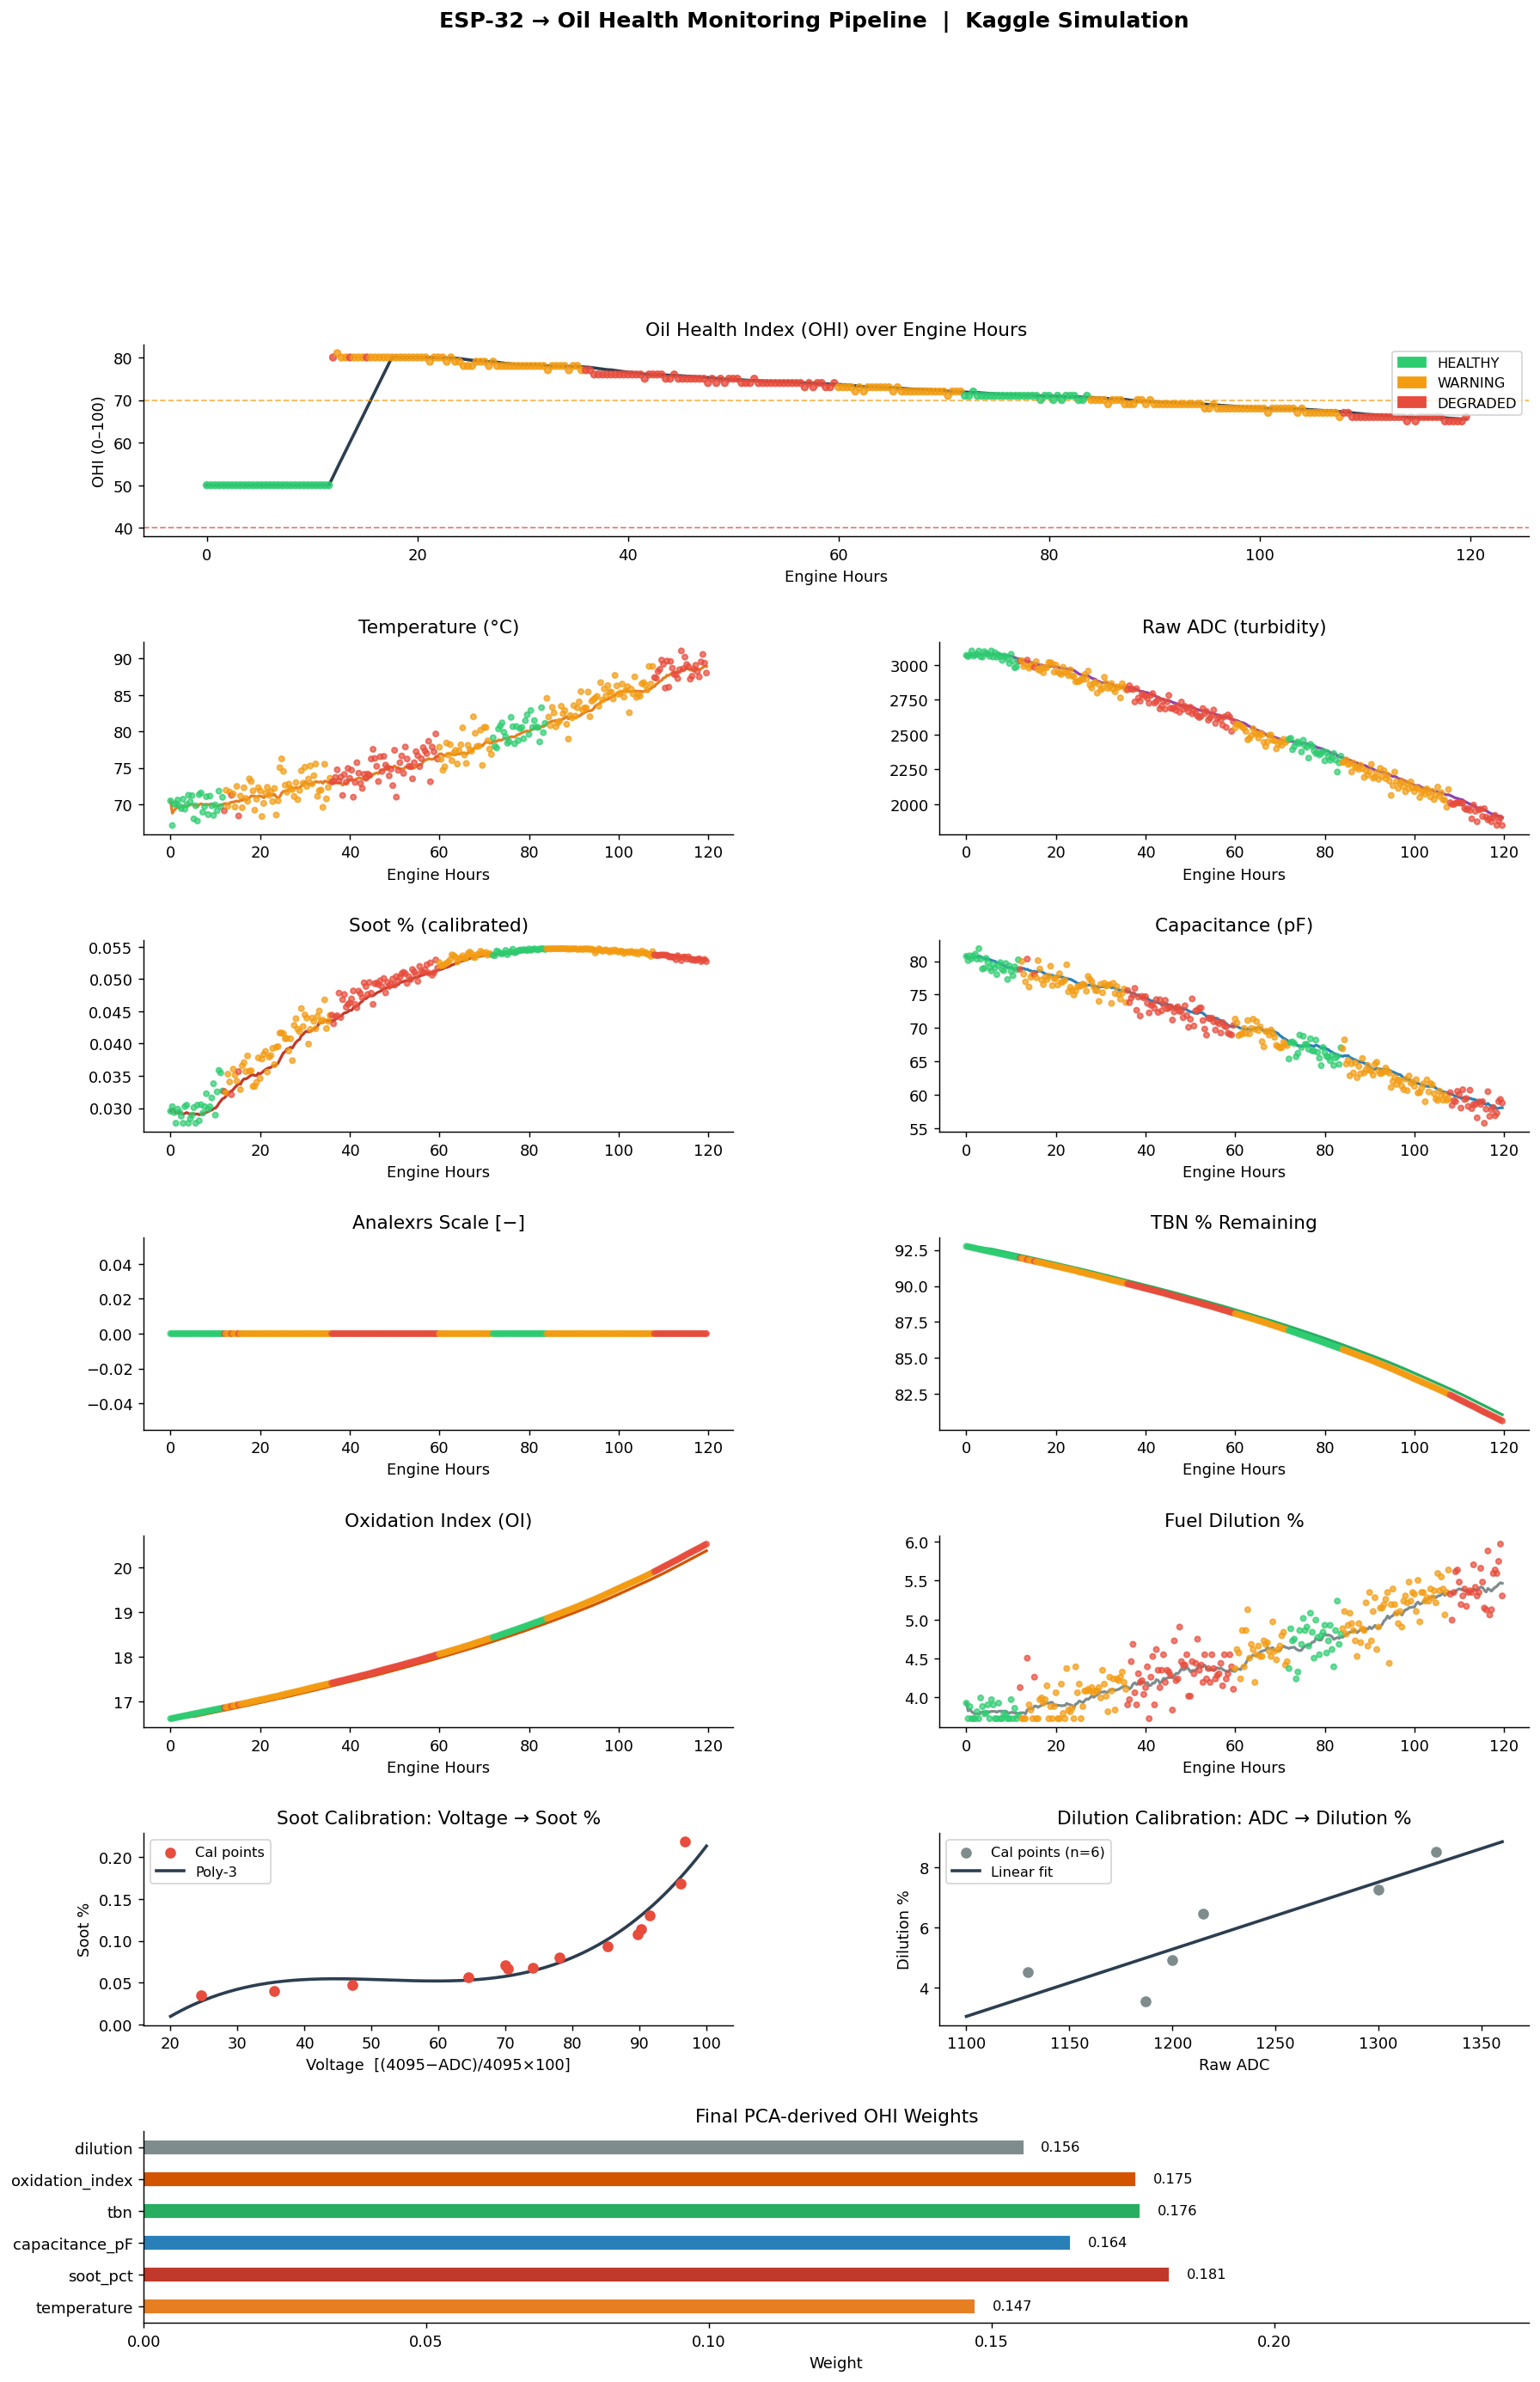

Dashboard saved → /kaggle/working/ohi_dashboard.png


In [24]:
LABEL_COLORS = {"HEALTHY": "#2ecc71", "WARNING": "#f39c12", "DEGRADED": "#e74c3c"}
COLOR_MAP    = df["cluster_label"].map(LABEL_COLORS)

fig = plt.figure(figsize=(16, 23))
gs  = GridSpec(7, 2, figure=fig, hspace=0.55, wspace=0.35)

# ── 1. OHI over engine hours (full width) ─────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
ax1.scatter(df["engine_hours"], df["ohi"], c=COLOR_MAP, s=18, alpha=0.8, zorder=3)
ax1.plot(df["engine_hours"], df["ohi"].rolling(15, min_periods=1).mean(),
         color="#2c3e50", lw=2)
ax1.axhline(70, color="#f39c12", lw=1, ls="--", alpha=0.7, label="Warning (70)")
ax1.axhline(40, color="#e74c3c", lw=1, ls="--", alpha=0.7, label="Degraded (40)")
patches = [mpatches.Patch(color=v, label=k) for k, v in LABEL_COLORS.items()]
ax1.legend(handles=patches, fontsize=9, loc="upper right")
ax1.set(title="Oil Health Index (OHI) over Engine Hours",
        xlabel="Engine Hours", ylabel="OHI (0–100)")

# ── 2. Sensor + derived signals ───────────────────────────────────────────────
signal_panels = [
    (gs[1, 0], "temperature",     "Temperature (°C)",          "#e67e22"),
    (gs[1, 1], "raw_adc",         "Raw ADC (turbidity)",       "#8e44ad"),
    (gs[2, 0], "soot_pct",        "Soot % (calibrated)",       "#c0392b"),
    (gs[2, 1], "capacitance_pF",  "Capacitance (pF)",          "#2980b9"),
    (gs[3, 0], "analexrs",        "Analexrs Scale [−]",        "#16a085"),
    (gs[3, 1], "tbn",             "TBN % Remaining",           "#27ae60"),
    (gs[4, 0], "oxidation_index", "Oxidation Index (OI)",      "#d35400"),
    (gs[4, 1], "dilution",        "Fuel Dilution %",           "#7f8c8d"),
]
for spec, col, title, color in signal_panels:
    ax = fig.add_subplot(spec)
    ax.scatter(df["engine_hours"], df[col], c=COLOR_MAP, s=12, alpha=0.7, zorder=3)
    ax.plot(df["engine_hours"], df[col].rolling(15, min_periods=1).mean(),
            color=color, lw=1.8)
    ax.set(title=title, xlabel="Engine Hours")

# ── 3. Soot calibration curve ─────────────────────────────────────────────────
ax_cal = fig.add_subplot(gs[5, 0])
cal_v    = np.array([row[1] for row in SOOT_CAL_DATA])
cal_soot = np.array([row[2] for row in SOOT_CAL_DATA])
v_range  = np.linspace(20, 100, 200)
coeffs   = np.polyfit(cal_v, cal_soot, 3)
ax_cal.scatter(cal_v, cal_soot, color="#e74c3c", zorder=3, label="Cal points")
ax_cal.plot(v_range, np.polyval(coeffs, v_range), color="#2c3e50", lw=2, label="Poly-3")
ax_cal.set(title="Soot Calibration: Voltage → Soot %",
           xlabel="Voltage  [(4095−ADC)/4095×100]", ylabel="Soot %")
ax_cal.legend(fontsize=9)

# ── 4. Dilution calibration line ──────────────────────────────────────────────
ax_dil = fig.add_subplot(gs[5, 1])
dil_adc = np.array([1187, 1130, 1215, 1200, 1300, 1328])
dil_pct = np.array([3.56, 4.53, 6.47, 4.909, 7.27, 8.51])
adc_range = np.linspace(1100, 1360, 200)
dil_fit   = -21.4218 + 0.022253 * adc_range
ax_dil.scatter(dil_adc, dil_pct, color="#7f8c8d", zorder=3, label="Cal points (n=6)")
ax_dil.plot(adc_range, dil_fit, color="#2c3e50", lw=2, label="Linear fit")
ax_dil.set(title="Dilution Calibration: ADC → Dilution %",
           xlabel="Raw ADC", ylabel="Dilution %")
ax_dil.legend(fontsize=9)

# ── 5. Final PCA weights ──────────────────────────────────────────────────────
ax_w = fig.add_subplot(gs[6, :])
final_weights = json.loads(df["pca_weights"].iloc[-1])
feats  = list(final_weights.keys())
vals   = [final_weights[f] for f in feats]
colors = ["#e67e22", "#c0392b", "#2980b9", "#27ae60", "#d35400", "#7f8c8d"]
bars   = ax_w.barh(feats, vals, color=colors, edgecolor="white", height=0.5)
for bar, v in zip(bars, vals):
    ax_w.text(v + 0.003, bar.get_y() + bar.get_height() / 2,
              f"{v:.3f}", va="center", fontsize=9)
ax_w.set(title="Final PCA-derived OHI Weights", xlabel="Weight")
ax_w.set_xlim(0, max(vals) * 1.35)

plt.suptitle("ESP-32 → Oil Health Monitoring Pipeline  |  Kaggle Simulation",
             fontsize=14, fontweight="bold", y=1.01)
out_png = "/kaggle/working/ohi_dashboard.png" if os.path.exists("/kaggle/working") else "ohi_dashboard.png"
plt.savefig(out_png, dpi=150, bbox_inches="tight")
plt.show()
print(f"Dashboard saved → {out_png}")


In [25]:
summary = (df.groupby("cluster_label")
             .agg(count           =("ohi",             "count"),
                  avg_ohi         =("ohi",             "mean"),
                  avg_tbn         =("tbn",             "mean"),
                  avg_temp        =("temperature",     "mean"),
                  avg_soot        =("soot_pct",        "mean"),
                  avg_adc         =("raw_adc",         "mean"),
                  avg_cap         =("capacitance_pF",  "mean"),
                  avg_analexrs    =("analexrs",        "mean"),
                  avg_oi          =("oxidation_index", "mean"),
                  avg_dilution    =("dilution",        "mean"))
             .round(4)
             .sort_values("avg_ohi", ascending=False))
print("=== Cluster Summary ===")
print(summary.to_string())

w_cols = [c for c in df.columns if c.startswith("w_")]
print("\n=== Final PCA OHI Weights ===")
for col in sorted(w_cols, key=lambda c: -df[col].iloc[-1]):
    w = df[col].iloc[-1]
    bar = "▓" * int(w * 100) + "░" * (20 - int(w * 100))
    print(f"  {col[2:]:<16}  {w:.4f}  [{bar}]")

print(f"\nTotal readings in DB: {len(df)}")
print(f"DB path: {DB_PATH}")


=== Cluster Summary ===
               count  avg_ohi  avg_tbn  avg_temp  avg_soot    avg_adc  avg_cap  avg_analexrs   avg_oi  avg_dilution
cluster_label                                                                                                      
WARNING          147  73.3129  87.4939   78.2276    0.0484  2520.4354  69.2705           0.0  18.2626        4.5806
DEGRADED          93  72.1183  86.7903   79.1681    0.0498  2461.1828  68.1156           0.0  18.4955        4.6640
HEALTHY           60  60.4333  89.3254   75.0505    0.0423  2718.5167  73.0385           0.0  17.6807        4.2737

=== Final PCA OHI Weights ===
  temperature       0.1471  [▓▓▓▓▓▓▓▓▓▓▓▓▓▓░░░░░░]
  soot_pct          0.1815  [▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓░░]
  capacitance_pF    0.1640  [▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓░░░░]
  tbn               0.1763  [▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓░░░]
  oxidation_index   0.1755  [▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓░░░]
  dilution          0.1557  [▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓░░░░░]

Total readings in DB: 300
DB path: /kaggle/working/oil_hea

In [26]:
out_dir  = "/kaggle/working" if os.path.exists("/kaggle/working") else "."
csv_path = f"{out_dir}/oil_health_results.csv"
df_export = df[[
    "engine_hours", "temperature", "raw_adc", "dilution_adc", "soot_pct",
    "capacitance_pF", "analexrs", "tbn", "oxidation_index", "dilution",
    "cluster_label", "ohi"
]].copy()
df_export.to_csv(csv_path, index=False)
print(f"Results CSV saved  →  {csv_path}")
print(df_export.tail())


Results CSV saved  →  /kaggle/working/oil_health_results.csv
     engine_hours  temperature  raw_adc  dilution_adc  soot_pct  \
295         118.0        87.48     1920          1216  0.053155   
296         118.4        89.54     1848          1214  0.052724   
297         118.8        90.57     1880          1221  0.052908   
298         119.2        89.37     1902          1231  0.053042   
299         119.6        88.01     1847          1201  0.052718   

     capacitance_pF  analexrs      tbn  oxidation_index  dilution  \
295           56.86       0.0  80.8842          20.4371    5.6378   
296           57.25       0.0  80.8197          20.4594    5.5933   
297           59.01       0.0  80.7516          20.4828    5.7491   
298           59.32       0.0  80.6878          20.5049    5.9716   
299           58.78       0.0  80.6288          20.5255    5.3041   

    cluster_label  ohi  
295      DEGRADED   65  
296      DEGRADED   65  
297      DEGRADED   65  
298      DEGRADED   6